# Basic gates and Pauli exponentials

In this notebook we will cover some basic quantum gates and learn how to express simple exponentials of Pauli operators in terms of these gates. If this material is already familiar to you, feel free to jump straight to the BONUS exercises at the end.

**NOTE:** The BONUS exercises cover more advanced material. They are not required preparation for the classes at the School, but they can be useful if you would like to explore further.


### Packages

Before using this notebook, make sure the following packages are installed in your Python environment:

- `qiskit` (versions 2.1.2 and 2.3.0 have been tested and work fine)
- `qiskit-aer` (version 0.17.2)
- `matplotlib` and `pylatexenc` (needed for Matplotlib circuit drawings)

If you have trouble installing the packages on your machine, you can run the notebook in [Google Colab](https://colab.research.google.com). In that case, run the following cell first.

In [ ]:
%pip install --quiet "qiskit==2.1.2" "qiskit-aer==0.17.2" matplotlib pylatexenc


## Single-qubit gates

Operations on a single qubit are represented by unitary matrices in $U(2)$. Since a global phase is not observable, we can describe physically distinct single-qubit gates using $SU(2)$ transformations.

Three matrices that will come in handy very often are the Pauli matrices

$$X=\begin{pmatrix}0&1\\1&0\end{pmatrix} \quad \quad Y=\begin{pmatrix}0&-i\\i&0\end{pmatrix} \quad\quad Z=\begin{pmatrix}1&0\\0&-1\end{pmatrix}.$$

Strictly speaking, $X$, $Y$, and $Z$ themselves have determinant $-1$, so they are not elements of $SU(2)$. Up to an unobservable global phase, however, they represent valid $SU(2)$ transformations. For those of you who like group theory: $iX$, $iY$, and $iZ$ form a basis of the Lie algebra $\mathfrak{su}(2)$, so any single-qubit $SU(2)$ gate can be written as the exponential of a linear combination of Pauli matrices.


A second set of very useful gates are the Hadamard gate $H$ and the phase gate $S$, defined as

$$H=\frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}\quad\quad S=\begin{pmatrix}1&0\\0&i\end{pmatrix}=\sqrt{Z}.$$

With the help of these gates we can change basis between the eigenvectors of $Z$, also known as the **computational basis** and often denoted by $\lvert0\rangle$ and $\lvert1\rangle$, and the eigenbases of $X$ or $Y$. In fact,

$$X=HZH\quad\quad Y=SXS^\dagger=SHZHS^\dagger.$$

This is particularly important in quantum computing because projective measurements are normally performed in the computational basis. This makes diagonal expectation values such as $\langle Z\rangle$ straightforward to estimate. To estimate, for example, $\langle X\rangle$ or $\langle Y\rangle$, we can first perform an appropriate basis change. We will see an example below.


Another useful family of single-qubit gates consists of rotations around the $X$, $Y$, and $Z$ axes, obtained through exponentiation. For instance,

$$R_X(\theta)=\exp\left(-i\frac{\theta}{2}X\right)=\begin{pmatrix} \cos(\theta/2)&-i\sin(\theta/2)\\-i\sin(\theta/2)&\cos(\theta/2)\end{pmatrix}$$

performs an $X$ rotation by an angle $\theta$. **Pay special attention to conventions such as the sign of the exponent and the factor $1/2$, since these conventions can differ between libraries.** For the gates available in Qiskit, see the [Qiskit circuit-library documentation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library).


### Example 1

In this first example we will write a circuit that prepares the single-qubit state

$$\lvert\Psi(\theta)\rangle = \cos(\theta)\lvert0\rangle+\sin(\theta)\lvert1\rangle$$

and measure the expectation values of the three Pauli matrices on the resulting state. The results are readily obtained as

$$\langle \Psi(\theta) \lvert X \rvert \Psi(\theta)\rangle = 2\cos(\theta)\sin(\theta)=\sin(2\theta),$$
$$\langle \Psi(\theta) \lvert Y \rvert \Psi(\theta)\rangle = 0,$$
$$\langle \Psi(\theta) \lvert Z \rvert \Psi(\theta)\rangle = \cos^2(\theta)-\sin^2(\theta)=\cos(2\theta).$$


Here is a simple Python snippet that performs the explicit calculation using `numpy`.


In [1]:
import numpy as np

# Define the Pauli matrices.
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1.j], [1.j, 0]])
Z = np.array([[1, 0], [0, -1]])

# Specify the value of theta.
theta = 0.2

# Perform the calculation.
psi = np.array([np.cos(theta), np.sin(theta)])
print(f"<X>: {np.vdot(psi, X @ psi)}\t{np.sin(2 * theta)}")
print(f"<Y>: {np.vdot(psi, Y @ psi)}\t{0}")
print(f"<Z>: {np.vdot(psi, Z @ psi)}\t{np.cos(2 * theta)}")

<X>: 0.38941834230865047	0.3894183423086505
<Y>: 1.2307929261577727e-17j	0
<Z>: 0.9210609940028851	0.9210609940028851


Here is the same preparation using `qiskit`.


Using Qiskit 2.3.0
Using Qiskit Aer 0.17.2


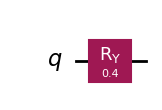

In [2]:
from importlib.metadata import version

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

print(f"Using Qiskit {version('qiskit')}")
print(f"Using Qiskit Aer {version('qiskit-aer')}")

# Specify the value of theta.
theta = 0.2

# Build a single-qubit circuit.
circ = QuantumCircuit(1)
quantum_bits = circ.qubits

# Use an RY gate on qubit 0 (pay attention to the factor of 1/2
# in the definition of RY).
circ.ry(2 * theta, quantum_bits[0])

# Visualize the circuit.
circ.draw("mpl")

# The command above requires pylatexenc. If needed, use:
# print(circ.draw("text"))

We can now compute the expectation values using an exact **statevector simulation**.


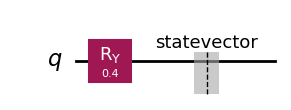

In [3]:
circ_sv = circ.copy()
circ_sv.save_statevector()
circ_sv.draw("mpl")

In [4]:
# Run the simulator and extract the resulting statevector.
sim_statevector = AerSimulator(method="statevector")
circ_sv_t = transpile(circ_sv, sim_statevector)
result_sv = sim_statevector.run(circ_sv_t).result()
outputstate_sv = result_sv.get_statevector(circ_sv_t, decimals=8)
print(outputstate_sv)

Statevector([0.98006658+0.j, 0.19866933+0.j],
            dims=(2,))


In [5]:
# Convert the result into a standard NumPy array.
psi_sv = np.asarray(outputstate_sv.data)

# Compute the resulting expectation values.
print(f"<X>: {np.vdot(psi_sv, X @ psi_sv)}\t{np.sin(2 * theta)}")
print(f"<Y>: {np.vdot(psi_sv, Y @ psi_sv)}\t{0}")
print(f"<Z>: {np.vdot(psi_sv, Z @ psi_sv)}\t{np.cos(2 * theta)}")

<X>: (0.38941834160798283+0j)	0.3894183423086505
<Y>: -6.9044005840922295e-18j	0
<Z>: (0.9210609985502475+0j)	0.9210609940028851


Note that Qiskit also provides several ways to evaluate expectation values directly from a `Statevector` object, without converting it to a NumPy array.


Using basis changes, we can obtain the same expectation values by measuring $Z$ on appropriately rotated circuits.


In [6]:
# For X, apply a Hadamard before measuring Z.
circ_x = circ.copy()
circ_x.h(0)
circ_x.save_statevector()
print(circ_x.draw("text"))

circ_x_t = transpile(circ_x, sim_statevector)
outputstate_x = sim_statevector.run(circ_x_t).result().get_statevector(circ_x_t, decimals=8)
psi_x = np.asarray(outputstate_x.data)

# We are now evaluating Z on the rotated state.
print(f"<X>: {np.vdot(psi_x, Z @ psi_x)}\t{np.sin(2 * theta)}")

   ┌─────────┐┌───┐ statevector 
q: ┤ Ry(0.4) ├┤ H ├──────░──────
   └─────────┘└───┘      ░      
<X>: (0.3894183376825583+0j)	0.3894183423086505


In [7]:
# For Y, apply S^dagger followed by H before measuring Z.
circ_y = circ.copy()
circ_y.sdg(0)
circ_y.h(0)
circ_y.save_statevector()
print(circ_y.draw("text"))

circ_y_t = transpile(circ_y, sim_statevector)
outputstate_y = sim_statevector.run(circ_y_t).result().get_statevector(circ_y_t, decimals=8)
psi_y = np.asarray(outputstate_y.data)

# We are now evaluating Z on the rotated state.
print(f"<Y>: {np.vdot(psi_y, Z @ psi_y)}\t{0}")

   ┌─────────┐┌─────┐┌───┐ statevector 
q: ┤ Ry(0.4) ├┤ Sdg ├┤ H ├──────░──────
   └─────────┘└─────┘└───┘      ░      
<Y>: (-1.5546759800974996e-17-5.771404800904634e-18j)	0


In [8]:
# For Z, no basis change is needed.
circ_z = circ.copy()
circ_z.save_statevector()
print(circ_z.draw("text"))

circ_z_t = transpile(circ_z, sim_statevector)
outputstate_z = sim_statevector.run(circ_z_t).result().get_statevector(circ_z_t, decimals=8)
psi_z = np.asarray(outputstate_z.data)

print(f"<Z>: {np.vdot(psi_z, Z @ psi_z)}\t{np.cos(2 * theta)}")

   ┌─────────┐ statevector 
q: ┤ Ry(0.4) ├──────░──────
   └─────────┘      ░      
<Z>: (0.9210609985502475+0j)	0.9210609940028851


- **EXERCISE 1:** Repeat the calculation using a **finite number of measurement shots** with `AerSimulator`. Estimate the three expectation values from the measurement outcomes and quantify their statistical uncertainties.


## Multi-qubit gates

With more than one qubit, we have access to entangling operations. A fundamental two-qubit gate is the controlled-NOT (CNOT or CX) gate.

If we write the basis states in the abstract order $\lvert c\,t\rangle$, with the control qubit first and the target qubit second, then

$$CNOT =
\begin{pmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&0&1\\
0&0&1&0
\end{pmatrix}
=
\lvert0\rangle\langle0\rvert\otimes\mathbb{1}
+
\lvert1\rangle\langle1\rvert\otimes X.$$

In circuit notation, a CNOT with `q_0` as control and `q_1` as target looks like this:


          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘
or also


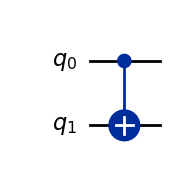

In [9]:
circ2a = QuantumCircuit(2)
circ2a.cx(0,1)
print(circ2a.draw('text'))
print("or also")
circ2a.draw('mpl')

The notation for the CNOT gate in the text drawing makes the role of the Pauli $X$ explicit. The line joins a **control** qubit to a **target** qubit: the operation $X$ is applied to the target only when the control is in the $\lvert1\rangle$ state.

Writing the kets below in the order $\lvert q_0 q_1\rangle$,

$$CNOT(q_0,q_1)\lvert00\rangle=\lvert00\rangle,$$
$$CNOT(q_0,q_1)\lvert01\rangle=\lvert01\rangle,$$
$$CNOT(q_0,q_1)\lvert10\rangle=\lvert11\rangle,$$
$$CNOT(q_0,q_1)\lvert11\rangle=\lvert10\rangle.$$

**Qiskit ordering note:** Qiskit labels `q_0` as the least-significant qubit, so statevector indices and displayed bit strings use the opposite visual order, with `q_0` on the right. Keep this in mind when comparing matrices, ket labels, and Qiskit output.


The CNOT operation is directional, so it is useful to write it as $CNOT(q_c,q_t)$, where $q_c$ is the control qubit and $q_t$ is the target qubit. The operation above is therefore $CNOT(q_0,q_1)$. Reversing control and target gives $CNOT(q_1,q_0)$:


     ┌───┐
q_0: ┤ X ├
     └─┬─┘
q_1: ──■──
          
or also


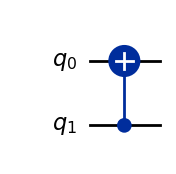

In [10]:
circ2b = QuantumCircuit(2)
circ2b.cx(1,0)
print(circ2b.draw('text'))
print("or also")
circ2b.draw('mpl')

Controlled operations appear throughout quantum computing because they let us condition one operation on the state of another qubit. For instance, if we want a controlled-$Z$ operation between `q_0` and `q_1`, we can use the identity $Z=HXH$:


                    
q_0: ───────■───────
     ┌───┐┌─┴─┐┌───┐
q_1: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘
or also


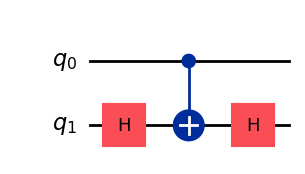

In [11]:
circ2c = QuantumCircuit(2)
circ2c.h(1)
circ2c.cx(0,1)
circ2c.h(1)
print(circ2c.draw('text'))
print("or also")
circ2c.draw('mpl')

The Hadamard gates perform the required change of basis between $X$ and $Z$. The resulting operation has its own name, the controlled-$Z$ or $CZ$ gate, and is directly available in Qiskit:


        
q_0: ─■─
      │ 
q_1: ─■─
        
or also


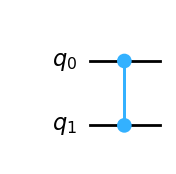

In [12]:
circ2d = QuantumCircuit(2)
circ2d.cz(0,1)
print(circ2d.draw('text'))
print("or also")
circ2d.draw('mpl')

This notation also makes it apparent that $CZ(q_0,q_1)=CZ(q_1,q_0)$: unlike CNOT, the controlled-$Z$ gate is symmetric under exchange of the two qubits.


A remarkable fact is that CNOT together with arbitrary single-qubit gates forms a **universal gate set**. In particular, any two-qubit unitary in $SU(4)$ can be implemented using at most three CNOT gates together with single-qubit operations (see, for example, [here](https://arxiv.org/pdf/quant-ph/0307177) and [here](https://arxiv.org/pdf/quant-ph/0308006)).

More generally, any $n$-qubit unitary can be decomposed exactly into CNOTs and single-qubit gates, although a generic $n$-qubit unitary requires a number of gates that grows exponentially with $n$ (see, for example, [here](https://arxiv.org/pdf/cond-mat/9407022) and [here](https://arxiv.org/pdf/quant-ph/9505016)).

We can also replace the continuous set of arbitrary single-qubit gates by a finite universal gate set. For example, $H$, $T=\sqrt{S}$, and CNOT can approximate arbitrary unitaries to any desired accuracy. The cost of achieving higher precision can be controlled systematically; see, for example, [here](https://arxiv.org/pdf/quant-ph/0403025), [here](https://arxiv.org/pdf/quant-ph/0505030), and [here](https://arxiv.org/pdf/1403.2975). This is one of the key ideas behind gate-based universal quantum computation.


- **EXERCISE 2:** Show that the following circuit is equivalent to $CNOT(q_1,q_0)$.


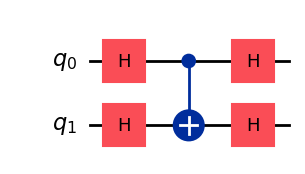

In [13]:
circ_e2 = QuantumCircuit(2)
circ_e2.h(0)
circ_e2.h(1)
circ_e2.cx(0,1)
circ_e2.h(0)
circ_e2.h(1)
circ_e2.draw('mpl')

- **EXERCISE 3:** Show that the following circuit is equivalent to a controlled-$Z$ rotation of the form

$$CR_Z(\theta)=\begin{pmatrix}\mathbb{1}&0\\0&R_Z(\theta)\end{pmatrix},$$

where the individual blocks are $2\times2$ matrices. How would you modify the circuit to perform $CR_X(\theta)$ instead?


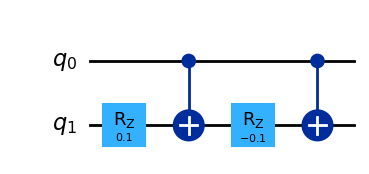

In [14]:
## here theta can be any angle of your choosing
theta = 0.2
circ_e3 = QuantumCircuit(2)
circ_e3.rz(theta/2,1)
circ_e3.cx(0,1)
circ_e3.rz(-theta/2,1)
circ_e3.cx(0,1)
circ_e3.draw('mpl')

These constructions can be generalized to gates acting on more qubits. A standard three-qubit example is the Toffoli gate (controlled-controlled-$X$):

$$TOFF =
\begin{pmatrix}
1&0&0&0&0&0&0&0\\
0&1&0&0&0&0&0&0\\
0&0&1&0&0&0&0&0\\
0&0&0&1&0&0&0&0\\
0&0&0&0&1&0&0&0\\
0&0&0&0&0&1&0&0\\
0&0&0&0&0&0&0&1\\
0&0&0&0&0&0&1&0
\end{pmatrix}
=
\left(
\lvert00\rangle\langle00\rvert+
\lvert01\rangle\langle01\rvert+
\lvert10\rangle\langle10\rvert
\right)\otimes\mathbb{1}
+
\lvert11\rangle\langle11\rvert\otimes X.$$

Here the first two subsystems in the formula are the controls and the third is the target. In circuit notation:


          
q_0: ──■──
       │  
q_1: ──■──
     ┌─┴─┐
q_2: ┤ X ├
     └───┘
or also


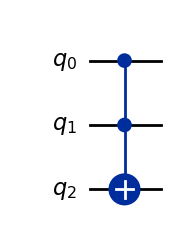

In [15]:
circ3a = QuantumCircuit(3)
circ3a.ccx(0,1,2)
print(circ3a.draw('text'))
print("or also")
circ3a.draw('mpl')

- **EXERCISE 4:** What operation does the following circuit implement? Your answer should be an operator identity, so it should not depend on the input state.


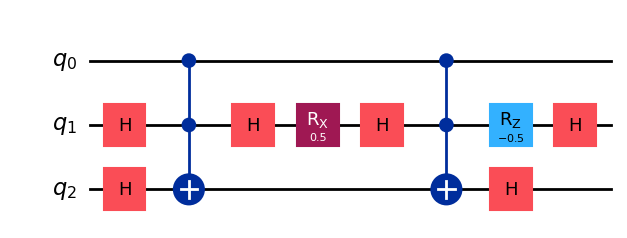

In [16]:
circ_e4 = QuantumCircuit(3)
circ_e4.h([1,2])
circ_e4.ccx(0,1,2)
circ_e4.h(1)
circ_e4.rx(0.5,1)
circ_e4.h(1)
circ_e4.ccx(0,1,2)
circ_e4.rz(-0.5,1)
circ_e4.h([1,2])
circ_e4.draw('mpl')

- **EXERCISE 5:** What does the following circuit do? Show that the final result is independent of the rotation angles $\theta$ and $\phi$.
    - **NOTE:** When the circuit is executed as written, all qubits start in $\lvert0\rangle$.


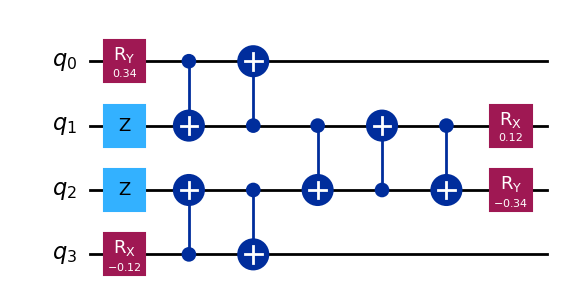

In [17]:
theta=0.34
phi=0.12

circ_e5 = QuantumCircuit(4)
circ_e5.ry(theta,0)
circ_e5.z([1,2])
circ_e5.rx(-phi,3)
circ_e5.cx(0,1)
circ_e5.cx(3,2)
circ_e5.cx(1,0)
circ_e5.cx(2,3)
circ_e5.cx(1,2)
circ_e5.cx(2,1)
circ_e5.cx(1,2)
circ_e5.ry(-theta,2)
circ_e5.rx(phi,1)
circ_e5.draw('mpl')

**HINTS:**
- Try choosing a simple pair of angles for which you can find the final state easily. What do you get?
- To understand what is happening, consider the following sub-circuit separately. What does it do to an arbitrary two-qubit state?


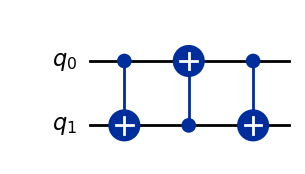

In [18]:
circ_e5p = QuantumCircuit(2)
circ_e5p.cx(0,1)
circ_e5p.cx(1,0)
circ_e5p.cx(0,1)
circ_e5p.draw('mpl')

## Exponentials of Pauli matrices

We have already encountered single-qubit rotations corresponding to exponentials of Pauli matrices. What happens if instead we want a multi-qubit rotation such as

$$U_A(\theta)=\exp(-i\theta Z_0Z_1),\quad
U_B(\theta)=\exp(-i\theta X_0X_2),\quad
U_C(\theta)=\exp(-i\theta X_0X_1X_2),\quad
U_D(\theta)=\exp(-i\theta X_0Z_1Y_2)?$$

The implementation of these operations can be understood using two useful CNOT conjugation identities:

- a $Z$ operator on the **control** commutes through a CNOT;
- moving a $Z$ operator on the **target** through a CNOT produces a $Z$ on both control and target.

The following circuits illustrate these identities.


In [19]:
circ_ep1a = QuantumCircuit(2)
circ_ep1a.z(0)
circ_ep1a.cx(0, 1)
print("This circuit")
print(circ_ep1a.draw("text"))

circ_ep1b = QuantumCircuit(2)
circ_ep1b.cx(0, 1)
circ_ep1b.z(0)
print("is equal to this circuit")
print(circ_ep1b.draw("text"))
print("for every input state.")

This circuit
     ┌───┐     
q_0: ┤ Z ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
is equal to this circuit
          ┌───┐
q_0: ──■──┤ Z ├
     ┌─┴─┐└───┘
q_1: ┤ X ├─────
     └───┘     
for every input state.


In [20]:
circ_ep1c = QuantumCircuit(2)
circ_ep1c.z(1)
circ_ep1c.cx(0, 1)
print("This circuit")
print(circ_ep1c.draw("text"))

circ_ep1d = QuantumCircuit(2)
circ_ep1d.cx(0, 1)
circ_ep1d.z([0, 1])
print("is equal to this circuit")
print(circ_ep1d.draw("text"))
print("for every input state.")

This circuit
               
q_0: ───────■──
     ┌───┐┌─┴─┐
q_1: ┤ Z ├┤ X ├
     └───┘└───┘
is equal to this circuit
          ┌───┐
q_0: ──■──┤ Z ├
     ┌─┴─┐├───┤
q_1: ┤ X ├┤ Z ├
     └───┘└───┘
for every input state.


Use these identities to show that $U_A(\theta)$ can be implemented by either of the following circuits.


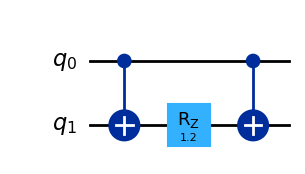

In [21]:
## here we pick some value for theta just for the example (the value does not matter)
theta=0.6
circ_ua1 = QuantumCircuit(2)
circ_ua1.cx(0,1)
circ_ua1.rz(2*theta,1)
circ_ua1.cx(0,1)
circ_ua1.draw('mpl')

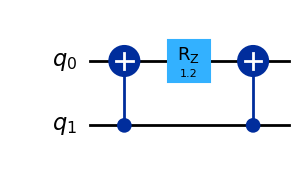

In [22]:
## here we pick some value for theta just for the example (the value does not matter)
theta=0.6
circ_ua2 = QuantumCircuit(2)
circ_ua2.cx(1,0)
circ_ua2.rz(2*theta,0)
circ_ua2.cx(1,0)
circ_ua2.draw('mpl')

- **EXERCISE 6:** Use what you learned above to construct circuits for the other Pauli exponentials on a three-qubit system. Try to find as many equivalent implementations as possible. Test that they implement the intended operation using statevector simulations and compare with an independent exact matrix calculation.


Two very useful references for basic circuit constructions and manipulations are [this paper](https://arxiv.org/pdf/quant-ph/9503016) and [this review](https://arxiv.org/abs/1110.2998). Many of the techniques in the first reference are especially useful pedagogically; modern circuit-compilation methods can be substantially more efficient. If you are curious, see for example [this paper](https://arxiv.org/abs/1003.5760) and [this more recent work](https://arxiv.org/abs/2510.07223) for a flavor of gate-synthesis and compilation methods.


### BONUS EXERCISE 1: quantum state teleportation

Quantum teleportation is a communication protocol in which a quantum state is transferred from a sender, whom we will call Sandy, to a receiver, Rick, using shared entanglement together with classical communication. The protocol works as follows:

- Sandy has one qubit, which we call $B_\Psi$, in a state she wants to send to Rick. For this example, use $\lvert\Psi(\theta)\rangle$ from Example 1 above.
- Before the protocol begins, Sandy and Rick prepare a two-qubit Bell state
  $$\lvert B\rangle=\frac{\lvert00\rangle+\lvert11\rangle}{\sqrt{2}}.$$
  They keep one qubit each; call Sandy's qubit $B_S$ and Rick's qubit $B_R$.

The protocol then proceeds as follows:

1. Sandy applies a CNOT from $B_\Psi$ to $B_S$. The total state on $(B_\Psi,B_S,B_R)$ becomes
   $$\frac{\cos(\theta)}{\sqrt{2}}\lvert0\rangle\otimes\left(\lvert00\rangle+\lvert11\rangle\right)
   +\frac{\sin(\theta)}{\sqrt{2}}\lvert1\rangle\otimes\left(\lvert10\rangle+\lvert01\rangle\right).$$

2. She applies a Hadamard gate to $B_\Psi$, obtaining
   $$\frac{\lvert00\rangle}{2}\otimes\left(\cos(\theta)\lvert0\rangle+\sin(\theta)\lvert1\rangle\right)
   +\frac{\lvert01\rangle}{2}\otimes\left(\cos(\theta)\lvert1\rangle+\sin(\theta)\lvert0\rangle\right)
   +\frac{\lvert10\rangle}{2}\otimes\left(\cos(\theta)\lvert0\rangle-\sin(\theta)\lvert1\rangle\right)
   +\frac{\lvert11\rangle}{2}\otimes\left(\cos(\theta)\lvert1\rangle-\sin(\theta)\lvert0\rangle\right).$$

3. Sandy measures her two qubits and sends the two classical outcomes to Rick.

4. Rick can recover the state $\lvert\Psi\rangle$ on $B_R$ by applying a Pauli correction that depends on Sandy's measurement outcome:
   - no operation for $(B_\Psi,B_S)=(0,0)$;
   - $X$ for $(B_\Psi,B_S)=(0,1)$;
   - $Z$ for $(B_\Psi,B_S)=(1,0)$;
   - $XZ$ for $(B_\Psi,B_S)=(1,1)$.

Show that Rick's qubit indeed ends in the desired state. Then implement the protocol with Qiskit. For example, after completing the protocol you can measure $B_R$ and compare the statistics with those expected from the original state $\lvert\Psi(\theta)\rangle$.

The code below is only a **starting point**: it implements the Bell-basis measurement and the classically controlled corrections, but intentionally leaves the state preparation and Bell-pair preparation for you to complete.


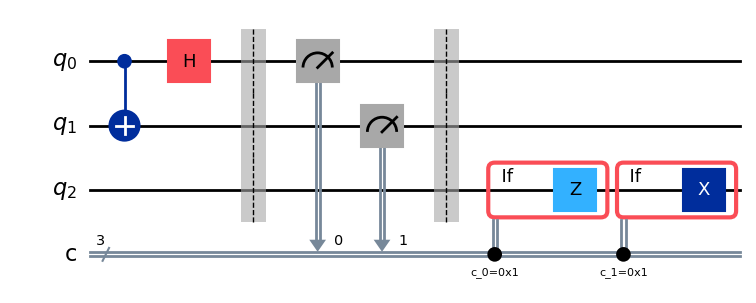

In [23]:
# Define a circuit with 3 qubits and 3 classical bits.
telep_circ = QuantumCircuit(3, 3)

# Store labels for the three qubits and classical bits.
quantum_bits = telep_circ.qubits
classical_bits = telep_circ.clbits

# TODO: prepare the input state on B_psi and the Bell pair shared by Sandy and Rick.

# Sandy's Bell-basis measurement.
telep_circ.cx(quantum_bits[0], quantum_bits[1])
telep_circ.h(quantum_bits[0])

telep_circ.barrier()
telep_circ.measure(quantum_bits[0], classical_bits[0])
telep_circ.measure(quantum_bits[1], classical_bits[1])

# Classical feed-forward corrections on Rick's qubit.
telep_circ.barrier()

# Apply Z to B_R if the measurement of B_psi is 1.
with telep_circ.if_test((classical_bits[0], 1)):
    telep_circ.z(quantum_bits[2])

# Apply X to B_R if the measurement of B_S is 1.
with telep_circ.if_test((classical_bits[1], 1)):
    telep_circ.x(quantum_bits[2])

telep_circ.draw("mpl")

### BONUS EXERCISE 2: circuit detective

If you already know everything about `qiskit`, circuits and quantum teleportation try to use your skills to understand what this circuit is doing

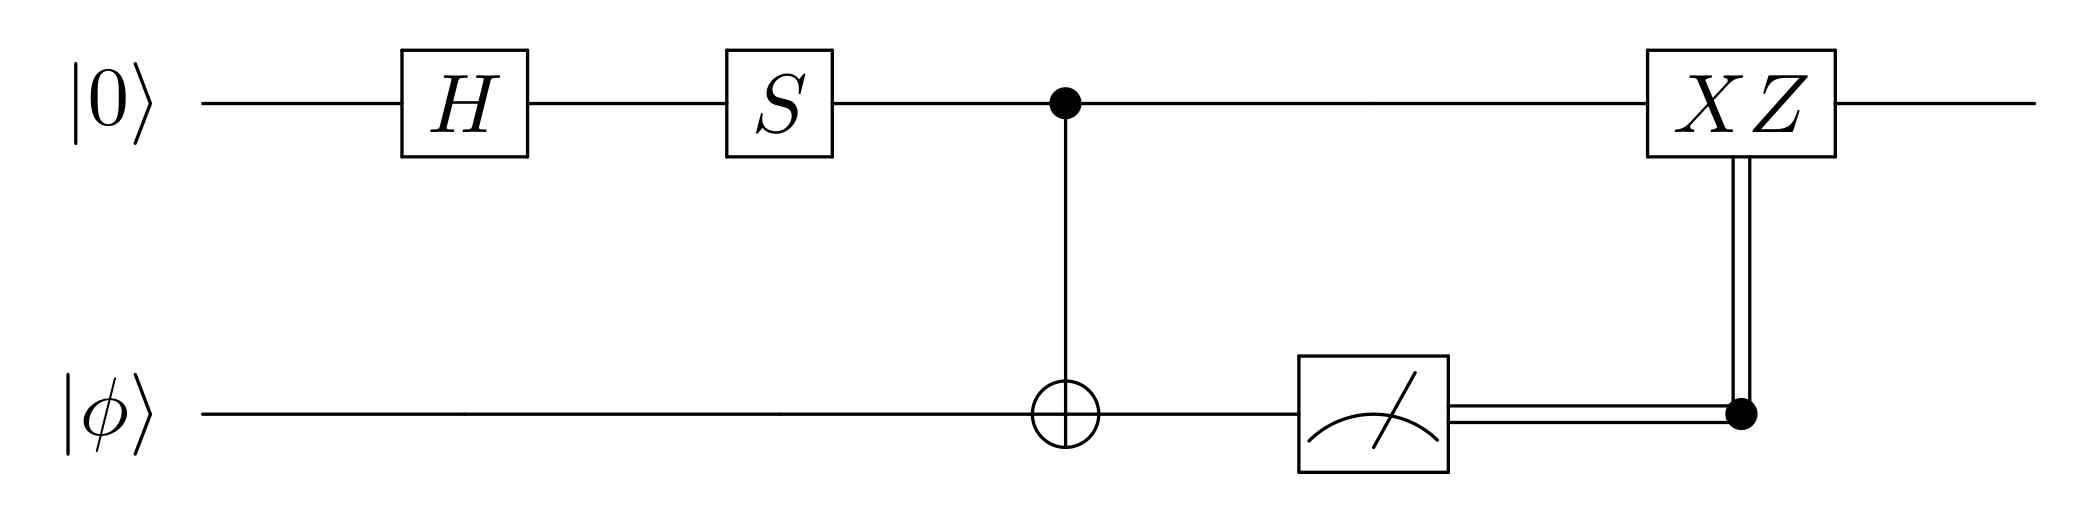

The $\rvert\phi\rangle$ on the second qubit is completely generic and the double lines are used for classical controls (like above for state teleportation).

- try to understand what state is left on the first qubit
- can you find a way to achieve the same functionality but without measuring the second qubit at all?
- and how about a version without any controls **after** the measurement?
- if in the original circuit instead of the gates $S$ we used $T=\sqrt{S}$, what classically controlled operation should we use to get the same type of functionality?
- why would a circuit like this be useful?

The second and fourth question are the toughest. A hint for the latter is that $T$ gates are really difficult to implement with active error correction. A hint for the former is to check out, if you never heard of it, what **oblivious amplitude amplification** is [here](https://arxiv.org/pdf/1312.1414) or [here](https://arxiv.org/abs/1412.4687).